In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)

from warnings import filterwarnings
filterwarnings('ignore')

df = pd.read_csv(r'F:\Data Analytics\Jupyter Notebook\Projects\AlexTheAnalyst\movies.csv')

In [2]:
df.head()

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year
0,19000000.0,Warner Bros.,United Kingdom,Stanley Kubrick,Drama,46998772.0,The Shining,R,"June 13, 1980 (United States)",146.0,8.4,Jack Nicholson,927000.0,Stephen King,1980
1,4500000.0,Columbia Pictures,United States,Randal Kleiser,Adventure,58853106.0,The Blue Lagoon,R,"July 2, 1980 (United States)",104.0,5.8,Brooke Shields,65000.0,Henry De Vere Stacpoole,1980
2,18000000.0,Lucasfilm,United States,Irvin Kershner,Action,538375067.0,Star Wars: Episode V - The Empire Strikes Back,PG,"June 20, 1980 (United States)",124.0,8.7,Mark Hamill,1200000.0,Leigh Brackett,1980
3,3500000.0,Paramount Pictures,United States,Jim Abrahams,Comedy,83453539.0,Airplane!,PG,"July 2, 1980 (United States)",88.0,7.7,Robert Hays,221000.0,Jim Abrahams,1980
4,6000000.0,Orion Pictures,United States,Harold Ramis,Comedy,39846344.0,Caddyshack,R,"July 25, 1980 (United States)",98.0,7.3,Chevy Chase,108000.0,Brian Doyle-Murray,1980


In [3]:
# Check for Missing Data
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print(f"{col} - {round(pct_missing,1)}%")

budget - 0.3%
company - 0.0%
country - 0.0%
director - 0.0%
genre - 0.0%
gross - 0.0%
name - 0.0%
rating - 0.0%
released - 0.0%
runtime - 0.0%
score - 0.0%
star - 0.0%
votes - 0.0%
writer - 0.0%
year - 0.0%


In [4]:
df = df.dropna()

In [5]:
df.dtypes

budget      float64
company         str
country         str
director        str
genre           str
gross       float64
name            str
rating          str
released        str
runtime     float64
score       float64
star            str
votes       float64
writer          str
year          int64
dtype: object

In [6]:
# Changing Datatype of columns
df["budget"] = df["budget"].astype("int64")

df["gross"] = df["gross"].astype("int64")

In [7]:
df

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year
0,19000000,Warner Bros.,United Kingdom,Stanley Kubrick,Drama,46998772,The Shining,R,"June 13, 1980 (United States)",146.0,8.4,Jack Nicholson,927000.0,Stephen King,1980
1,4500000,Columbia Pictures,United States,Randal Kleiser,Adventure,58853106,The Blue Lagoon,R,"July 2, 1980 (United States)",104.0,5.8,Brooke Shields,65000.0,Henry De Vere Stacpoole,1980
2,18000000,Lucasfilm,United States,Irvin Kershner,Action,538375067,Star Wars: Episode V - The Empire Strikes Back,PG,"June 20, 1980 (United States)",124.0,8.7,Mark Hamill,1200000.0,Leigh Brackett,1980
3,3500000,Paramount Pictures,United States,Jim Abrahams,Comedy,83453539,Airplane!,PG,"July 2, 1980 (United States)",88.0,7.7,Robert Hays,221000.0,Jim Abrahams,1980
4,6000000,Orion Pictures,United States,Harold Ramis,Comedy,39846344,Caddyshack,R,"July 25, 1980 (United States)",98.0,7.3,Chevy Chase,108000.0,Brian Doyle-Murray,1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7648,90000000,Columbia Pictures,United States,Adil El Arbi,Action,426505244,Bad Boys for Life,R,"January 17, 2020 (United States)",124.0,6.6,Will Smith,140000.0,Peter Craig,2020
7649,85000000,Paramount Pictures,United States,Jeff Fowler,Action,319715683,Sonic the Hedgehog,PG,"February 14, 2020 (United States)",99.0,6.5,Ben Schwartz,102000.0,Pat Casey,2020
7650,175000000,Universal Pictures,United States,Stephen Gaghan,Adventure,245487753,Dolittle,PG,"January 17, 2020 (United States)",101.0,5.6,Robert Downey Jr.,53000.0,Stephen Gaghan,2020
7651,135000000,20th Century Studios,Canada,Chris Sanders,Adventure,111105497,The Call of the Wild,PG,"February 21, 2020 (United States)",100.0,6.8,Harrison Ford,42000.0,Michael Green,2020


In [8]:
# Creating corrected year column
df["yearCorrect"] = df["released"].astype(str).str.extract(r"(\d{4})")
df

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year,yearCorrect
0,19000000,Warner Bros.,United Kingdom,Stanley Kubrick,Drama,46998772,The Shining,R,"June 13, 1980 (United States)",146.0,8.4,Jack Nicholson,927000.0,Stephen King,1980,1980
1,4500000,Columbia Pictures,United States,Randal Kleiser,Adventure,58853106,The Blue Lagoon,R,"July 2, 1980 (United States)",104.0,5.8,Brooke Shields,65000.0,Henry De Vere Stacpoole,1980,1980
2,18000000,Lucasfilm,United States,Irvin Kershner,Action,538375067,Star Wars: Episode V - The Empire Strikes Back,PG,"June 20, 1980 (United States)",124.0,8.7,Mark Hamill,1200000.0,Leigh Brackett,1980,1980
3,3500000,Paramount Pictures,United States,Jim Abrahams,Comedy,83453539,Airplane!,PG,"July 2, 1980 (United States)",88.0,7.7,Robert Hays,221000.0,Jim Abrahams,1980,1980
4,6000000,Orion Pictures,United States,Harold Ramis,Comedy,39846344,Caddyshack,R,"July 25, 1980 (United States)",98.0,7.3,Chevy Chase,108000.0,Brian Doyle-Murray,1980,1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7648,90000000,Columbia Pictures,United States,Adil El Arbi,Action,426505244,Bad Boys for Life,R,"January 17, 2020 (United States)",124.0,6.6,Will Smith,140000.0,Peter Craig,2020,2020
7649,85000000,Paramount Pictures,United States,Jeff Fowler,Action,319715683,Sonic the Hedgehog,PG,"February 14, 2020 (United States)",99.0,6.5,Ben Schwartz,102000.0,Pat Casey,2020,2020
7650,175000000,Universal Pictures,United States,Stephen Gaghan,Adventure,245487753,Dolittle,PG,"January 17, 2020 (United States)",101.0,5.6,Robert Downey Jr.,53000.0,Stephen Gaghan,2020,2020
7651,135000000,20th Century Studios,Canada,Chris Sanders,Adventure,111105497,The Call of the Wild,PG,"February 21, 2020 (United States)",100.0,6.8,Harrison Ford,42000.0,Michael Green,2020,2020


In [9]:
df = df.sort_values(by=["gross"], inplace=False, ascending=False)

In [10]:
# Drop Duplicates
df.drop_duplicates()

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year,yearCorrect
5445,237000000,Twentieth Century Fox,United States,James Cameron,Action,2847246203,Avatar,PG-13,"December 18, 2009 (United States)",162.0,7.8,Sam Worthington,1100000.0,James Cameron,2009,2009
7445,356000000,Marvel Studios,United States,Anthony Russo,Action,2797501328,Avengers: Endgame,PG-13,"April 26, 2019 (United States)",181.0,8.4,Robert Downey Jr.,903000.0,Christopher Markus,2019,2019
3045,200000000,Twentieth Century Fox,United States,James Cameron,Drama,2201647264,Titanic,PG-13,"December 19, 1997 (United States)",194.0,7.8,Leonardo DiCaprio,1100000.0,James Cameron,1997,1997
6663,245000000,Lucasfilm,United States,J.J. Abrams,Action,2069521700,Star Wars: Episode VII - The Force Awakens,PG-13,"December 18, 2015 (United States)",138.0,7.8,Daisy Ridley,876000.0,Lawrence Kasdan,2015,2015
7244,321000000,Marvel Studios,United States,Anthony Russo,Action,2048359754,Avengers: Infinity War,PG-13,"April 27, 2018 (United States)",149.0,8.4,Robert Downey Jr.,897000.0,Christopher Markus,2018,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5640,3000000,Two Prong Lesson,United States,Francesca Gregorini,Drama,5073,Tanner Hall,R,"January 15, 2015 (Sweden)",96.0,5.8,Rooney Mara,3500.0,Tatiana von Fürstenberg,2009,2015
2434,5000000,Trimark Pictures,United States,Stephen Cornwell,Action,2970,Philadelphia Experiment II,PG-13,"June 4, 1994 (South Korea)",97.0,4.5,Brad Johnson,1900.0,Wallace C. Bennett,1993,1994
3681,5000000,Copperheart Entertainment,Canada,John Fawcett,Drama,2554,Ginger Snaps,Not Rated,"May 11, 2001 (Canada)",108.0,6.8,Emily Perkins,43000.0,Karen Walton,2000,2001
272,800000,Embassy Pictures,United States,Charles Band,Horror,2270,Parasite,R,"March 12, 1982 (United States)",85.0,3.9,Robert Glaudini,2300.0,Alan J. Adler,1982,1982


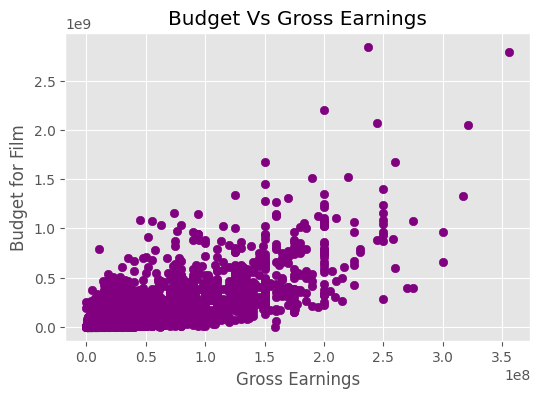

In [30]:
# Scatter plot with budget vs gross

plt.figure(figsize=(6, 4))
plt.scatter(x=df["budget"], y=df["gross"], color='purple')
plt.title("Budget Vs Gross Earnings")

plt.xlabel("Gross Earnings")
plt.ylabel("Budget for Film")
plt.show()

<Axes: xlabel='budget', ylabel='gross'>

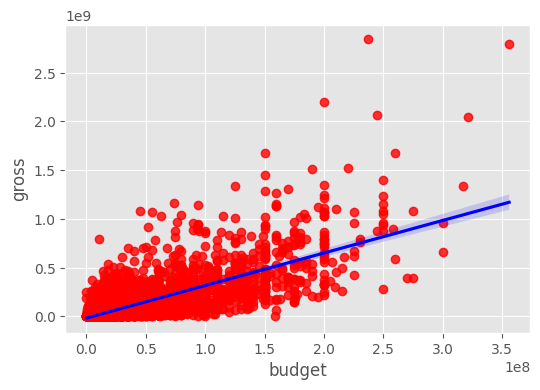

In [31]:
# Plot the budget vs gross
plt.figure(figsize=(6, 4))
sns.regplot(x='budget', y='gross', data=df, scatter_kws={'color': 'r'}, line_kws={'color':'blue'})

In [13]:
df.head()

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year,yearCorrect
5445,237000000,Twentieth Century Fox,United States,James Cameron,Action,2847246203,Avatar,PG-13,"December 18, 2009 (United States)",162.0,7.8,Sam Worthington,1100000.0,James Cameron,2009,2009
7445,356000000,Marvel Studios,United States,Anthony Russo,Action,2797501328,Avengers: Endgame,PG-13,"April 26, 2019 (United States)",181.0,8.4,Robert Downey Jr.,903000.0,Christopher Markus,2019,2019
3045,200000000,Twentieth Century Fox,United States,James Cameron,Drama,2201647264,Titanic,PG-13,"December 19, 1997 (United States)",194.0,7.8,Leonardo DiCaprio,1100000.0,James Cameron,1997,1997
6663,245000000,Lucasfilm,United States,J.J. Abrams,Action,2069521700,Star Wars: Episode VII - The Force Awakens,PG-13,"December 18, 2015 (United States)",138.0,7.8,Daisy Ridley,876000.0,Lawrence Kasdan,2015,2015
7244,321000000,Marvel Studios,United States,Anthony Russo,Action,2048359754,Avengers: Infinity War,PG-13,"April 27, 2018 (United States)",149.0,8.4,Robert Downey Jr.,897000.0,Christopher Markus,2018,2018


In [14]:
# df['gross'] = pd.to_numeric(df['gross'], errors='coerce')
# df['budget'] = pd.to_numeric(df['budget'], errors='coerce')

In [15]:
df.corr(numeric_only=True, method='pearson')

,budget,gross,runtime,score,votes,year
budget,1.000000,0.740247,0.318695,0.072001,0.439675,0.327722
gross,0.740247,1.000000,0.275796,0.222556,0.614751,0.274321
runtime,0.318695,0.275796,1.000000,0.414068,0.352303,0.075077
score,0.072001,0.222556,0.414068,1.000000,0.474256,0.056386
votes,0.439675,0.614751,0.352303,0.474256,1.000000,0.206021
year,0.327722,0.274321,0.075077,0.056386,0.206021,1.000000


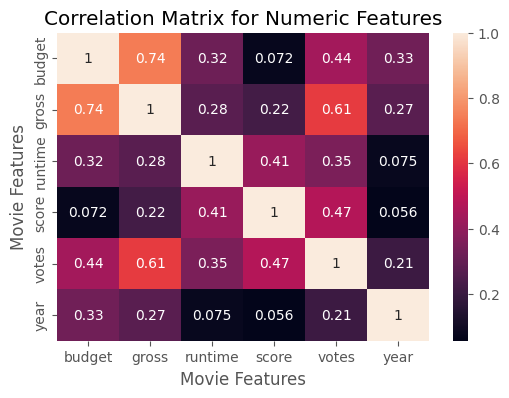

In [24]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(6, 4)) 
sns.heatmap(correlation_matrix, annot=True)

plt.title("Correlation Matrix for Numeric Features")
plt.xlabel("Movie Features")
plt.ylabel("Movie Features")

plt.show()

In [17]:
df.dtypes

budget           int64
company            str
country            str
director           str
genre              str
gross            int64
name               str
rating             str
released           str
runtime        float64
score          float64
star               str
votes          float64
writer             str
year             int64
yearCorrect        str
dtype: object

In [18]:
df_numerized = df.copy()

df_numerized['company'] = df_numerized['company'].astype('category')
df_numerized['company'] = df_numerized['company'].cat.codes


df_numerized

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year,yearCorrect
5445,237000000,1382,United States,James Cameron,Action,2847246203,Avatar,PG-13,"December 18, 2009 (United States)",162.0,7.8,Sam Worthington,1100000.0,James Cameron,2009,2009
7445,356000000,983,United States,Anthony Russo,Action,2797501328,Avengers: Endgame,PG-13,"April 26, 2019 (United States)",181.0,8.4,Robert Downey Jr.,903000.0,Christopher Markus,2019,2019
3045,200000000,1382,United States,James Cameron,Drama,2201647264,Titanic,PG-13,"December 19, 1997 (United States)",194.0,7.8,Leonardo DiCaprio,1100000.0,James Cameron,1997,1997
6663,245000000,945,United States,J.J. Abrams,Action,2069521700,Star Wars: Episode VII - The Force Awakens,PG-13,"December 18, 2015 (United States)",138.0,7.8,Daisy Ridley,876000.0,Lawrence Kasdan,2015,2015
7244,321000000,983,United States,Anthony Russo,Action,2048359754,Avengers: Infinity War,PG-13,"April 27, 2018 (United States)",149.0,8.4,Robert Downey Jr.,897000.0,Christopher Markus,2018,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5640,3000000,1385,United States,Francesca Gregorini,Drama,5073,Tanner Hall,R,"January 15, 2015 (Sweden)",96.0,5.8,Rooney Mara,3500.0,Tatiana von Fürstenberg,2009,2015
2434,5000000,1376,United States,Stephen Cornwell,Action,2970,Philadelphia Experiment II,PG-13,"June 4, 1994 (South Korea)",97.0,4.5,Brad Johnson,1900.0,Wallace C. Bennett,1993,1994
3681,5000000,466,Canada,John Fawcett,Drama,2554,Ginger Snaps,Not Rated,"May 11, 2001 (Canada)",108.0,6.8,Emily Perkins,43000.0,Karen Walton,2000,2001
272,800000,582,United States,Charles Band,Horror,2270,Parasite,R,"March 12, 1982 (United States)",85.0,3.9,Robert Glaudini,2300.0,Alan J. Adler,1982,1982


In [19]:
df

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year,yearCorrect
5445,237000000,Twentieth Century Fox,United States,James Cameron,Action,2847246203,Avatar,PG-13,"December 18, 2009 (United States)",162.0,7.8,Sam Worthington,1100000.0,James Cameron,2009,2009
7445,356000000,Marvel Studios,United States,Anthony Russo,Action,2797501328,Avengers: Endgame,PG-13,"April 26, 2019 (United States)",181.0,8.4,Robert Downey Jr.,903000.0,Christopher Markus,2019,2019
3045,200000000,Twentieth Century Fox,United States,James Cameron,Drama,2201647264,Titanic,PG-13,"December 19, 1997 (United States)",194.0,7.8,Leonardo DiCaprio,1100000.0,James Cameron,1997,1997
6663,245000000,Lucasfilm,United States,J.J. Abrams,Action,2069521700,Star Wars: Episode VII - The Force Awakens,PG-13,"December 18, 2015 (United States)",138.0,7.8,Daisy Ridley,876000.0,Lawrence Kasdan,2015,2015
7244,321000000,Marvel Studios,United States,Anthony Russo,Action,2048359754,Avengers: Infinity War,PG-13,"April 27, 2018 (United States)",149.0,8.4,Robert Downey Jr.,897000.0,Christopher Markus,2018,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5640,3000000,Two Prong Lesson,United States,Francesca Gregorini,Drama,5073,Tanner Hall,R,"January 15, 2015 (Sweden)",96.0,5.8,Rooney Mara,3500.0,Tatiana von Fürstenberg,2009,2015
2434,5000000,Trimark Pictures,United States,Stephen Cornwell,Action,2970,Philadelphia Experiment II,PG-13,"June 4, 1994 (South Korea)",97.0,4.5,Brad Johnson,1900.0,Wallace C. Bennett,1993,1994
3681,5000000,Copperheart Entertainment,Canada,John Fawcett,Drama,2554,Ginger Snaps,Not Rated,"May 11, 2001 (Canada)",108.0,6.8,Emily Perkins,43000.0,Karen Walton,2000,2001
272,800000,Embassy Pictures,United States,Charles Band,Horror,2270,Parasite,R,"March 12, 1982 (United States)",85.0,3.9,Robert Glaudini,2300.0,Alan J. Adler,1982,1982


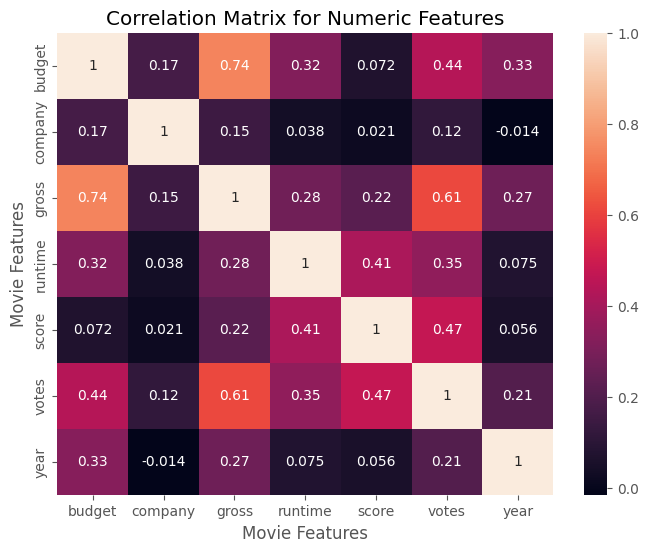

In [20]:
correlation_matrix = df_numerized.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True)

plt.title("Correlation Matrix for Numeric Features")
plt.xlabel("Movie Features")
plt.ylabel("Movie Features")
    
plt.show()

In [21]:
correlation_mat = df_numerized.corr(numeric_only=True)
corr_pairs = correlation_mat.unstack()
corr_pairs

budget   budget     1.000000
         company    0.170235
         gross      0.740247
         runtime    0.318695
         score      0.072001
         votes      0.439675
         year       0.327722
company  budget     0.170235
         company    1.000000
         gross      0.149553
         runtime    0.037585
         score      0.020656
         votes      0.118470
         year      -0.014333
gross    budget     0.740247
         company    0.149553
         gross      1.000000
         runtime    0.275796
         score      0.222556
         votes      0.614751
         year       0.274321
runtime  budget     0.318695
         company    0.037585
         gross      0.275796
         runtime    1.000000
         score      0.414068
         votes      0.352303
         year       0.075077
score    budget     0.072001
         company    0.020656
         gross      0.222556
         runtime    0.414068
         score      1.000000
         votes      0.474256
         year 

In [22]:
sorted_pairs = corr_pairs.sort_values()
sorted_pairs

company  year      -0.014333
year     company   -0.014333
score    company    0.020656
company  score      0.020656
runtime  company    0.037585
company  runtime    0.037585
score    year       0.056386
year     score      0.056386
budget   score      0.072001
score    budget     0.072001
year     runtime    0.075077
runtime  year       0.075077
company  votes      0.118470
votes    company    0.118470
gross    company    0.149553
company  gross      0.149553
         budget     0.170235
budget   company    0.170235
votes    year       0.206021
year     votes      0.206021
gross    score      0.222556
score    gross      0.222556
year     gross      0.274321
gross    year       0.274321
         runtime    0.275796
runtime  gross      0.275796
budget   runtime    0.318695
runtime  budget     0.318695
year     budget     0.327722
budget   year       0.327722
votes    runtime    0.352303
runtime  votes      0.352303
         score      0.414068
score    runtime    0.414068
votes    budge

In [23]:
high_corr= sorted_pairs[(sorted_pairs) > 0.5]
high_corr

gross    votes      0.614751
votes    gross      0.614751
gross    budget     0.740247
budget   gross      0.740247
         budget     1.000000
runtime  runtime    1.000000
score    score      1.000000
gross    gross      1.000000
company  company    1.000000
votes    votes      1.000000
year     year       1.000000
dtype: float64